In [1]:
#Chuẩn bị thư viện
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch, find_peaks

In [2]:
#Lấy danh sách record 1xx
all_records = wfdb.get_record_list('mitdb')
records_1xx = [r for r in all_records if r.startswith('1')]

print(records_1xx)
print("Total:", len(records_1xx))


['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124']
Total: 23


In [3]:
#load các record
ecg_data = {}

for rec in records_1xx:
    try:
        record = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

        ecg_data[rec] = {
            "signal": record.p_signal[:, 0],  # MLII
            "fs": record.fs,
            "r_peaks": ann.sample,
            "labels": ann.symbol
        }

        print(f"Loaded record {rec}")

    except Exception as e:
        print(f"Failed to load record {rec}: {e}")


Loaded record 100
Loaded record 101
Loaded record 102
Loaded record 103
Loaded record 104
Loaded record 105
Loaded record 106
Loaded record 107
Loaded record 108
Loaded record 109
Loaded record 111
Loaded record 112
Loaded record 113
Loaded record 114
Loaded record 115
Loaded record 116
Loaded record 117
Loaded record 118
Loaded record 119
Loaded record 121
Loaded record 122
Loaded record 123
Loaded record 124


In [4]:
# Kiểm tra dữ liệu đã tải
print(ecg_data['100'].keys())

dict_keys(['signal', 'fs', 'r_peaks', 'labels'])


In [5]:
# Kiểm tra độ dài tín hiệu và số điểm R-peak
print(len(ecg_data['100']['signal']))
print(len(ecg_data['100']['r_peaks']))


650000
2274


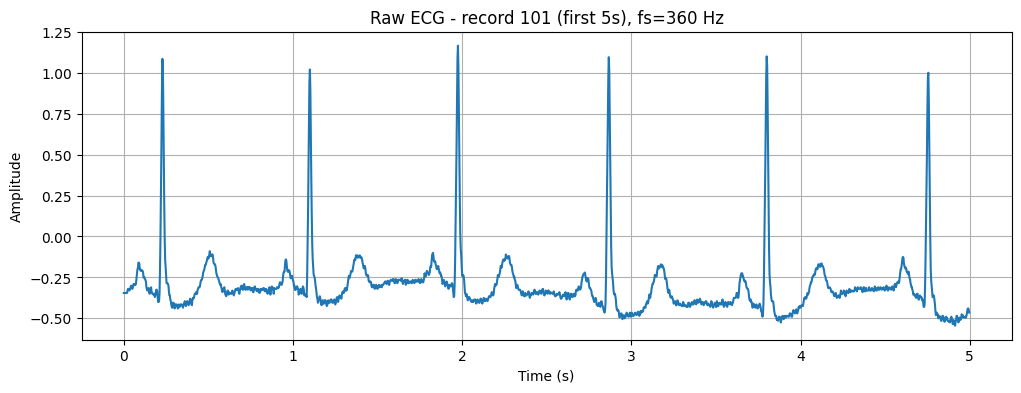

Sampling rate (fs): 360 Hz
Signal length: 650000 samples ~ 1805.5555555555557 seconds
Number of annotated R-peaks: 1874


In [6]:
#vẽ ECG thô (ví dụ record 101, lead MLII)
rec_id = "101"      # đổi record nếu muốn
seconds = 5         # số giây muốn xem

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]

n = min(int(seconds * fs), len(ecg_raw))
t = np.arange(n) / fs

plt.figure(figsize=(12,4))
plt.plot(t, ecg_raw[:n])
plt.title(f"Raw ECG - record {rec_id} (first {seconds}s), fs={fs} Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print("Sampling rate (fs):", fs, "Hz")
print("Signal length:", len(ecg_raw), "samples ~", len(ecg_raw)/fs, "seconds")
print("Number of annotated R-peaks:", len(ecg_data[rec_id]["r_peaks"]))

## Filtering visualization (record 2xx)

Mục tiêu: **mỗi bước lọc = 1 cell**, và mỗi cell đều vẽ **Before vs After** (time-domain + PSD) để thấy thay đổi rõ ràng:
1) Loại bỏ dao động đường cơ sở (baseline wander)  
2) Loại bỏ nhiễu điện lưới (notch 50/60 Hz)  
3) Bộ lọc thông dải 0.5–40 Hz  


In [ ]:
# CELL A — Setup đường dẫn dữ liệu MIT-BIH (mitdb) + đảm bảo có file local
# - Nếu bạn đã có folder ./mitdb chứa *.dat/*.hea: code sẽ dùng luôn (không tải lại)
# - Nếu chưa có: code sẽ tự tải mitdb về ./mitdb bằng wfdb.dl_database

import os
from pathlib import Path
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch, medfilt

PROJECT_DIR = Path().resolve()
DATA_DIR = PROJECT_DIR / "mitdb"
DATA_DIR.mkdir(exist_ok=True)

def have_record_files(record_id: str, data_dir: Path) -> bool:
    return (data_dir / f"{record_id}.dat").exists() and (data_dir / f"{record_id}.hea").exists()

# chọn record 2xx bạn muốn (đổi số tại đây)
record_id = "200"  # ví dụ: "201", "202", ...

# Nếu chưa có file record local thì tải toàn bộ mitdb (1 lần)
if not have_record_files(record_id, DATA_DIR):
    print(f"Không thấy {record_id}.dat/.hea trong {DATA_DIR}. Đang tải mitdb về local...")
    wfdb.dl_database("mitdb", dl_dir=str(DATA_DIR))
else:
    print(f"OK: Đã có dữ liệu local cho record {record_id} trong {DATA_DIR}")

print("DATA_DIR =", DATA_DIR)


In [ ]:
# CELL B — Helper plots + filters (dùng cho các cell sau)
def _odd(n: int) -> int:
    n = int(n)
    if n < 3: n = 3
    return n if n % 2 == 1 else n + 1

def plot_time_compare(x_before, x_after, fs, start_s=0, win_s=10, title="Time-domain (Before vs After)"):
    i0 = int(start_s * fs)
    i1 = int((start_s + win_s) * fs)
    i1 = min(i1, len(x_before), len(x_after))
    t = np.arange(i0, i1) / fs
    plt.figure()
    plt.plot(t, x_before[i0:i1], label="before", alpha=0.7)
    plt.plot(t, x_after[i0:i1], label="after",  alpha=0.9)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

def plot_psd_compare(x_before, x_after, fs, fmax=120, title="PSD (Welch) (Before vs After)"):
    nper = min(4096, len(x_before))
    f1, P1 = welch(x_before, fs=fs, nperseg=nper)
    f2, P2 = welch(x_after,  fs=fs, nperseg=nper)
    plt.figure()
    plt.semilogy(f1, P1, label="before", alpha=0.8)
    plt.semilogy(f2, P2, label="after",  alpha=0.9)
    plt.xlim(0, fmax)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.legend()
    plt.show()

def remove_baseline_median(x, fs, w1_s=0.2, w2_s=0.6):
    """Baseline wander removal (robust):
    baseline = medfilt(medfilt(x, w1), w2); detrended = x - baseline
    """
    w1 = _odd(round(w1_s * fs))
    w2 = _odd(round(w2_s * fs))
    b1 = medfilt(x, kernel_size=w1)
    baseline = medfilt(b1, kernel_size=w2)
    return x - baseline, baseline

def notch_filter(x, fs, f0=50.0, Q=30):
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)
    return filtfilt(b, a, x)

def bandpass_05_40(x, fs, order=4):
    b, a = butter(order, [0.5, 40.0], btype="bandpass", fs=fs)
    return filtfilt(b, a, x)

def detect_mains_from_psd(x, fs):
    """Chọn 50 hay 60 dựa trên peak PSD (±1Hz)."""
    nper = min(4096, len(x))
    f, P = welch(x, fs=fs, nperseg=nper)

    def peak_near(target, bw=1.0):
        m = (f >= target - bw) & (f <= target + bw)
        return float(np.max(P[m])) if np.any(m) else 0.0

    p50 = peak_near(50.0, 1.0)
    p60 = peak_near(60.0, 1.0)
    return 50.0 if p50 >= p60 else 60.0


In [ ]:
# CELL C — Load record 2xx (local) + Visualize RAW (Before)
# đọc record từ đường dẫn local: DATA_DIR/record_id
rec_path = str(DATA_DIR / record_id)

record = wfdb.rdrecord(rec_path)
fs = float(record.fs)

# chọn lead MLII nếu có
sig_names = list(getattr(record, "sig_name", [])) if getattr(record, "sig_name", None) is not None else []
ch = sig_names.index("MLII") if ("MLII" in sig_names) else 0

x_raw = record.p_signal[:, ch].astype(float)

print("record_id:", record_id)
print("fs:", fs)
print("lead:", sig_names[ch] if sig_names else f"ch{ch}")

# Visualize raw
plot_time_compare(x_raw, x_raw, fs, start_s=0, win_s=10, title=f"RAW ECG (record {record_id})")
plot_psd_compare(x_raw, x_raw, fs, fmax=120, title=f"RAW PSD (record {record_id})")


In [ ]:
# CELL D — (1) Loại bỏ dao động đường cơ sở (Baseline wander) — Before vs After
x_detrended, baseline = remove_baseline_median(x_raw, fs, w1_s=0.2, w2_s=0.6)

plot_time_compare(
    x_raw, x_detrended, fs,
    start_s=0, win_s=10,
    title="Baseline removal — Before (raw) vs After (detrended)"
)

# show baseline ước lượng (để thấy cái gì bị trừ đi)
n = int(10 * fs)
t = np.arange(n) / fs
plt.figure()
plt.plot(t, x_raw[:n], label="raw", alpha=0.7)
plt.plot(t, baseline[:n], label="estimated baseline", alpha=0.9)
plt.title("Estimated Baseline (component removed)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# PSD low-frequency focus
plot_psd_compare(
    x_raw, x_detrended, fs,
    fmax=30,
    title="Baseline removal — PSD (0–30 Hz)"
)


In [ ]:
# CELL E — (2) Loại bỏ nhiễu điện lưới (Notch 50/60 Hz) — Before vs After
mains = detect_mains_from_psd(x_detrended, fs)
Q = 30
print(f"Detected mains: {mains:.0f} Hz | Q={Q}")

x_notched = notch_filter(x_detrended, fs, f0=mains, Q=Q)

plot_time_compare(
    x_detrended, x_notched, fs,
    start_s=0, win_s=10,
    title=f"Notch {mains:.0f} Hz — Before vs After"
)

plot_psd_compare(
    x_detrended, x_notched, fs,
    fmax=120,
    title=f"Notch {mains:.0f} Hz — PSD Before vs After"
)

# zoom quanh mains để thấy 'cọc' biến mất rõ hơn
f_zoom = 80 if mains == 60 else 70
plot_psd_compare(
    x_detrended, x_notched, fs,
    fmax=f_zoom,
    title=f"Notch {mains:.0f} Hz — PSD Zoom"
)


In [ ]:
# CELL F — (3) Bộ lọc thông dải 0.5–40 Hz — Before vs After
x_bandpassed = bandpass_05_40(x_notched, fs, order=4)

plot_time_compare(
    x_notched, x_bandpassed, fs,
    start_s=0, win_s=10,
    title="Band-pass 0.5–40 Hz — Before vs After"
)

plot_psd_compare(
    x_notched, x_bandpassed, fs,
    fmax=120,
    title="Band-pass 0.5–40 Hz — PSD Before vs After"
)


In [ ]:
# CELL G — Tổng kết: RAW vs FINAL (baseline + notch + band-pass)
x_final = x_bandpassed

plot_time_compare(
    x_raw, x_final, fs,
    start_s=0, win_s=10,
    title="FINAL — RAW vs (baseline + notch + band-pass)"
)

plot_psd_compare(
    x_raw, x_final, fs,
    fmax=120,
    title="FINAL — PSD RAW vs FINAL"
)


Xác định phức hợp QRS và trích xuất đăc trưng từ tín hiệu ECG

In [7]:
# 1) Truy cập dữ liệu WFDB (MIT-BIH)
def load_record(rec_id: str, lead_index: int = 0, pn_dir="mitdb", ann_ext="atr"):
    record = wfdb.rdrecord(rec_id, pn_dir=pn_dir)
    ann = wfdb.rdann(rec_id, ann_ext, pn_dir=pn_dir)

    ecg = record.p_signal[:, lead_index]
    fs = record.fs
    r_peaks = np.asarray(ann.sample, dtype=int)
    labels = np.asarray(ann.symbol)

    return ecg, fs, r_peaks, labels
def list_mitdb_records(prefix="1"):
    """List MIT-BIH records and optionally filter by prefix (e.g., '1' for 1xx)."""
    recs = wfdb.get_record_list("mitdb")
    if prefix is None:
        return recs
    return [r for r in recs if r.startswith(prefix)]

In [8]:
# 2) Lọc / Tiền xử lý
def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def notch_filter(x, fs, freq=50.0, q=30.0):
    nyq = fs / 2
    w0 = freq / nyq
    b, a = iirnotch(freq/nyq, q)
    return filtfilt(b, a, x)

def zscore_norm(x):
    s = np.std(x) + 1e-12
    return (x - np.mean(x)) / s

In [9]:
# 3) Phát hiện QRS 
def detect_r_peaks_pan_tompkins_like(x, fs):
    # bandpass nhấn mạnh QRS (~5–15Hz)
    xf = bandpass_filter(x, fs, low=5.0, high=15.0, order=2)

    # derivative + square
    dx = np.diff(xf, prepend=xf[0])
    sq = dx ** 2

    # moving window integrate ~150ms
    win = max(1, int(0.150 * fs))
    mwa = np.convolve(sq, np.ones(win) / win, mode="same")

    # find peaks
    min_dist = max(1, int(0.250 * fs))  # >=250ms
    thr = np.percentile(mwa, 95) * 0.3  # threshold tương đối
    peaks, _ = find_peaks(mwa, height=thr, distance=min_dist)

    # refine vị trí R: tìm max quanh peak trên x (±50ms)
    refined = []
    rad = max(1, int(0.050 * fs))
    for p in peaks:
        lo = max(0, p - rad)
        hi = min(len(x), p + rad + 1)
        refined.append(lo + int(np.argmax(x[lo:hi])))

    return np.unique(np.array(refined, dtype=int))

def get_r_peaks(ecg, fs, ann_r_peaks=None, mode="annotation"):
    if mode == "annotation":
        if ann_r_peaks is None:
            raise ValueError("Cần ann_r_peaks khi mode='annotation'")
        return np.asarray(ann_r_peaks, dtype=int)
    elif mode == "detect":
        return detect_r_peaks_pan_tompkins_like(ecg, fs)
    else:
        raise ValueError("mode phải là 'annotation' hoặc 'detect'")


In [10]:
# 4) EDA plots
def plot_ecg_with_r(ecg, r_peaks, fs, seconds=5, title="ECG + R-peaks"):
    n = min(int(seconds * fs), len(ecg))
    t = np.arange(n) / fs
    rp = np.asarray(r_peaks, dtype=int)
    rp = rp[rp < n]


    plt.figure(figsize=(12, 3))
    plt.plot(t, ecg[:n], label="ECG")
    plt.scatter(rp / fs, ecg[rp], s=12, marker="x", label="R-peaks")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

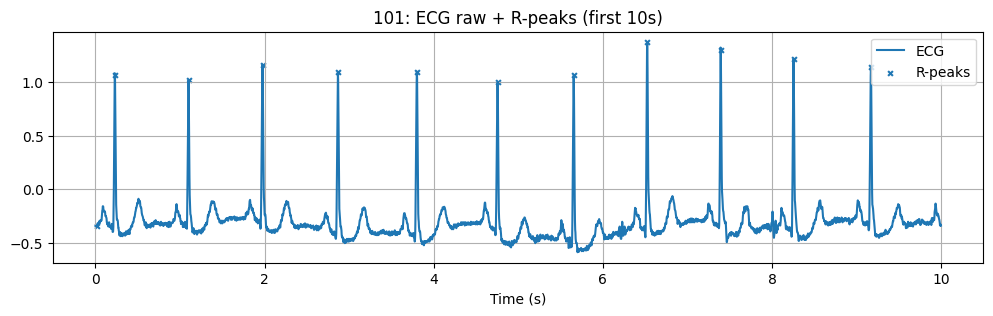

,r_idx,q_idx,s_idx,A_Q,A_R,A_S,QRS_width_ms
0,83,73,103,-0.400,1.065,-0.435,83.333333
1,396,389,413,-0.370,1.020,-0.405,66.666667
2,711,702,731,-0.370,1.165,-0.375,80.555556
3,1032,1023,1051,-0.465,1.095,-0.455,77.777778
4,1368,1359,1386,-0.490,1.100,-0.485,75.000000
5,1712,1702,1728,-0.430,1.000,-0.480,72.222222
6,2036,2023,2052,-0.545,1.065,-0.590,80.555556
7,2349,2341,2369,-0.450,1.375,-0.405,77.777778
8,2662,2654,2680,-0.365,1.305,-0.320,72.222222
9,2972,2963,2992,-0.445,1.220,-0.450,80.555556


count    1873.000000
mean       77.782227
std         5.506743
min         8.333333
25%        75.000000
50%        77.777778
75%        80.555556
max        94.444444
Name: QRS_width_ms, dtype: float64


In [11]:
#5 trích xuất đặc trưng QRS đơn giản
def extract_qrs_features_simple(ecg, r_peaks, fs):
    # Q: min trong [R-40ms, R-5ms]
    # S: min trong [R+5ms, R+60ms]
    q_left  = int(0.040 * fs)
    q_right = int(0.005 * fs)
    s_left  = int(0.005 * fs)
    s_right = int(0.060 * fs)

    feats = []
    r_peaks = np.asarray(r_peaks, dtype=int)

    for r in r_peaks:
        if r - q_left < 0 or r + s_right >= len(ecg):
            continue

        q_lo = r - q_left
        q_hi = r - q_right
        q_idx = q_lo + int(np.argmin(ecg[q_lo:q_hi]))

        s_lo = r + s_left
        s_hi = r + s_right
        s_idx = s_lo + int(np.argmin(ecg[s_lo:s_hi]))

        feats.append({
            "r_idx": int(r),
            "q_idx": int(q_idx),
            "s_idx": int(s_idx),
            "A_Q": float(ecg[q_idx]),
            "A_R": float(ecg[r]),
            "A_S": float(ecg[s_idx]),
            "QRS_width_ms": float((s_idx - q_idx) * 1000.0 / fs),
        })

    return pd.DataFrame(feats)

# Demo cho 1 record
rec_id = "101"
seconds = 10

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]
ann_r = ecg_data[rec_id]["r_peaks"]

# dùng annotation để identify QRS
r_peaks = get_r_peaks(ecg_raw, fs, ann_r_peaks=ann_r, mode="annotation")

# plot QRS
plot_ecg_with_r(ecg_raw, r_peaks, fs, seconds=seconds, title=f"{rec_id}: ECG raw + R-peaks (first {seconds}s)")

# other features (Q,S,QRS width)
df_qrs = extract_qrs_features_simple(ecg_raw, r_peaks, fs)
display(df_qrs.head(10))
print(df_qrs["QRS_width_ms"].describe())

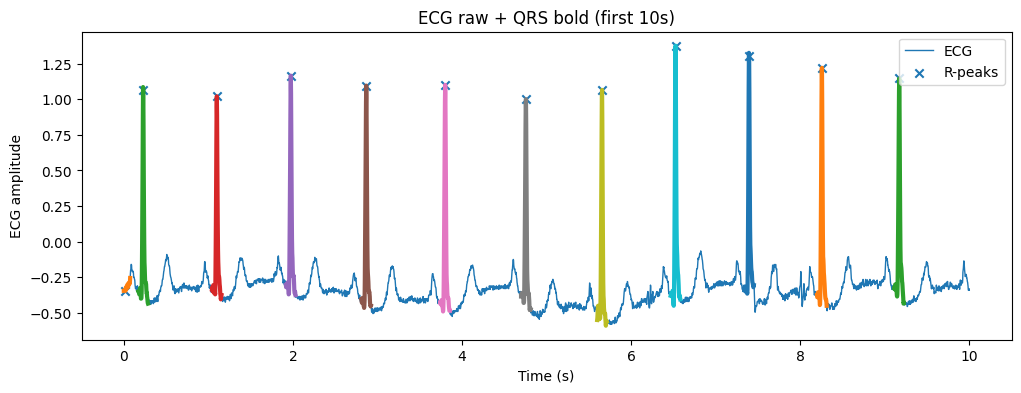

In [12]:
# Vẽ ECG với QRS in đậm (cửa sổ cố định quanh R-peak)
def plot_ecg_qrs_bold_window(ecg, fs, r_peaks, seconds=10, qrs_window_ms=120):
    """
    In đậm QRS bằng cách lấy cửa sổ cố định quanh mỗi R-peak.
    qrs_window_ms: độ rộng vùng QRS (ms), ví dụ 100–140ms
    """
    n = int(seconds * fs)
    ecg_seg = ecg[:n]
    t = np.arange(n) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(t, ecg_seg, linewidth=1, label="ECG")

    half = int((qrs_window_ms / 1000) * fs / 2)

    # In đậm các đoạn quanh R-peak
    for r in r_peaks:
        if r >= n:
            break
        s = max(0, r - half)
        e = min(n - 1, r + half)
        plt.plot(t[s:e], ecg_seg[s:e], linewidth=3)  # "in đậm"

    rp = np.array(r_peaks)
    rp = rp[rp < n]
    plt.scatter(rp / fs, ecg[rp], marker="x", label="R-peaks")

    plt.title(f"ECG raw + QRS bold (first {seconds}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("ECG amplitude")
    plt.legend()
    plt.show()
rec_id = "101"
record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
ecg = record.p_signal[:, 0]   # lead 0
fs = int(record.fs)
plot_ecg_qrs_bold_window(ecg, fs=360, r_peaks=r_peaks, seconds=10, qrs_window_ms=120)



Kiểm tra chất lượng tín hiệu ECG

In [13]:
# 1) Filters / baseline estimation
def butter_filter(x, fs, low=None, high=None, order=4):
    """General Butterworth filter. Provide low/high for bandpass, only low for highpass, only high for lowpass."""
    nyq = fs / 2
    if low is None and high is None:
        return x
    if low is not None and high is not None:
        btype = "band"
        Wn = [low/nyq, high/nyq]
    elif low is not None:
        btype = "high"
        Wn = low/nyq
    else:
        btype = "low"
        Wn = high/nyq
    b, a = butter(order, Wn, btype=btype)
    return filtfilt(b, a, x)

def estimate_baseline(ecg, fs, cutoff=0.5):
    """Baseline wander estimate via low-pass filtering (<0.5 Hz)."""
    return butter_filter(ecg, fs, high=cutoff, order=2)

In [14]:
# 2) Signal-level QC metrics
def psd_band_power(f, pxx, f1, f2):
    m = (f >= f1) & (f <= f2)
    if not np.any(m):
        return 0.0
    return float(np.trapz(pxx[m], f[m]))

def qc_signal_metrics(ecg, fs):
    """Compute baseline metrics + powerline ratios + HF noise ratio."""
    baseline = estimate_baseline(ecg, fs, cutoff=0.5)
    baseline_std = float(np.std(baseline))
    baseline_ptp = float(np.ptp(baseline))  # peak-to-peak

    # PSD
    f, pxx = welch(ecg, fs=fs, nperseg=min(len(ecg), 4096))

    p_0_40 = psd_band_power(f, pxx, 0.0, 40.0) + 1e-12
    p_49_51 = psd_band_power(f, pxx, 49.0, 51.0)
    p_59_61 = psd_band_power(f, pxx, 59.0, 61.0)
    p_20_40 = psd_band_power(f, pxx, 20.0, 40.0)

    powerline_50_ratio = float(p_49_51 / p_0_40)
    powerline_60_ratio = float(p_59_61 / p_0_40)
    hf_noise_ratio_20_40 = float(p_20_40 / p_0_40)

    # Raw amplitude stats
    amp_std = float(np.std(ecg))
    amp_min = float(np.min(ecg))
    amp_max = float(np.max(ecg))

    return {
        "baseline_std": baseline_std,
        "baseline_ptp": baseline_ptp,
        "powerline_50_ratio": powerline_50_ratio,
        "powerline_60_ratio": powerline_60_ratio,
        "hf_noise_ratio_20_40": hf_noise_ratio_20_40,
        "amp_std": amp_std,
        "amp_min": amp_min,
        "amp_max": amp_max,
        "baseline_series": baseline,
        "psd_f": f,
        "psd_pxx": pxx
    }


In [15]:
# 3) Beat-level QC (RR sanity)
def compute_rr(r_peaks, fs):
    """RR intervals in seconds."""
    r_peaks = np.array(r_peaks, dtype=int)
    if len(r_peaks) < 2:
        return np.array([], dtype=float)
    return np.diff(r_peaks) / fs

def qc_rr_metrics(r_peaks, fs, rr_min=0.3, rr_max=2.5):
    rr = compute_rr(r_peaks, fs)
    if len(rr) == 0:
        return {"rr_min": None, "rr_max": None, "bad_rr_pct": None, "bad_rr_idx": [], "rr": rr}

    bad = (rr < rr_min) | (rr > rr_max)
    bad_idx = np.where(bad)[0].tolist()

    return {
        "rr_min": float(np.min(rr)),
        "rr_max": float(np.max(rr)),
        "bad_rr_pct": float(100.0 * np.mean(bad)),
        "bad_rr_idx": bad_idx,
        "rr": rr
    }

In [16]:
# 4) Plotting (ECG+baseline, PSD, RR/HR hist)
def plot_ecg_with_baseline(ecg_raw, baseline, fs, seconds=10, title="ECG raw + baseline"):
    n = min(int(seconds * fs), len(ecg_raw))
    t = np.arange(n) / fs
    plt.figure(figsize=(12, 3))
    plt.plot(t, ecg_raw[:n], label="ECG raw")
    plt.plot(t, baseline[:n], label="Estimated baseline (<0.5Hz)")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_psd_welch_with_60_harmonics(
    x, fs,
    nperseg=None, noverlap=None, window="hann",
    fmax=360,                 # yêu cầu "<360" -> mình giới hạn tới min(fmax, fs/2)
    harmonic_base=60,         # bội số 60 Hz
    band_halfwidth=1.0,       # +/- 1 Hz quanh mỗi harmonic (tức band rộng 2 Hz)
    use_db=True,              # True: 10*log10(PSD)
    ax=None,
    title="PSD (Welch) with 60 Hz harmonics"
):
    x = np.asarray(x).astype(float)
    x = x - np.nanmean(x)

    # Welch params
    if nperseg is None:
        nperseg = min(len(x), int(fs * 4))  # mặc định 4s/cửa sổ
    if noverlap is None:
        noverlap = nperseg // 2

    f, pxx = welch(x, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, detrend="constant")

    # Giới hạn trục tần số: "<360" nhưng không vượt Nyquist
    fmax_eff = min(float(fmax), fs / 2.0)
    mask = (f >= 0) & (f <= fmax_eff)
    f_plot = f[mask]
    p_plot = pxx[mask]

    # Chuẩn bị trục
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    if use_db:
        y = 10 * np.log10(p_plot + 1e-20)
        ax.plot(f_plot, y, linewidth=1.2)
        ax.set_ylabel("PSD (dB/Hz)")
    else:
        ax.semilogy(f_plot, p_plot, linewidth=1.2)
        ax.set_ylabel("PSD (V²/Hz)")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Tô dải quanh các bội số của 60 Hz
    # (chỉ các harmonic <= fmax_eff)
    harmonics = np.arange(harmonic_base, fmax_eff + 1e-9, harmonic_base)
    for h in harmonics:
        left = max(0.0, h - band_halfwidth)
        right = min(fmax_eff, h + band_halfwidth)
        ax.axvspan(left, right, alpha=0.15)
        ax.axvline(h, linestyle="--", linewidth=1.0, alpha=0.6)

    ax.set_xlim(0, fmax_eff)
    return ax

def plot_rr_hist(rr, title="RR distribution"):
    plt.figure(figsize=(6, 4))
    plt.hist(rr, bins=50)
    plt.title(title)
    plt.xlabel("RR (s)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

def plot_hr_hist(rr, title="HR distribution"):
    if len(rr) == 0:
        print("No RR intervals to plot HR.")
        return
    hr = 60.0 / (rr + 1e-12)
    plt.figure(figsize=(6, 4))
    plt.hist(hr, bins=50)
    plt.title(title)
    plt.xlabel("HR (bpm)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

C:\Users\MY PC\AppData\Local\Temp\ipykernel_17380\382298698.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(pxx[m], f[m]))


,record_id,fs_hz,duration_s,num_beats,baseline_std,baseline_ptp,powerline_50_ratio,powerline_60_ratio,hf_noise_ratio_20_40,amp_std,amp_min,amp_max,rr_min,rr_max,bad_rr_pct
0,101,360,1805.555556,1874,0.117683,3.093681,0.000433,0.000763,0.083224,0.261156,-3.175,2.42,0.066667,1.275,0.427122


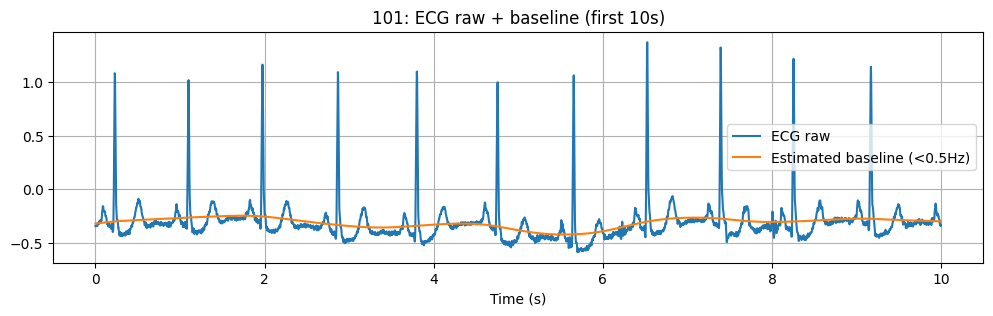

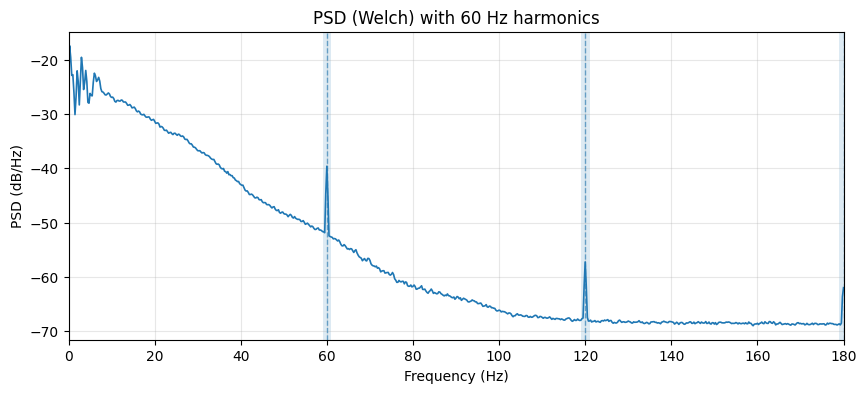

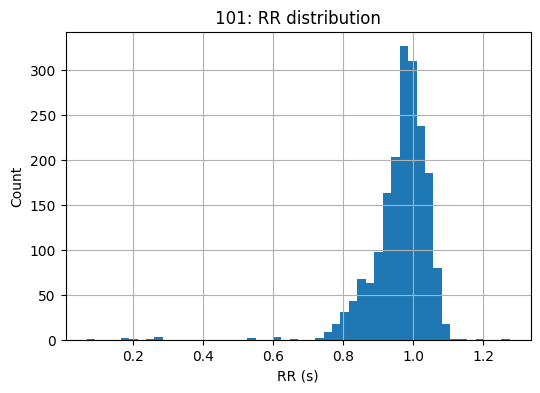

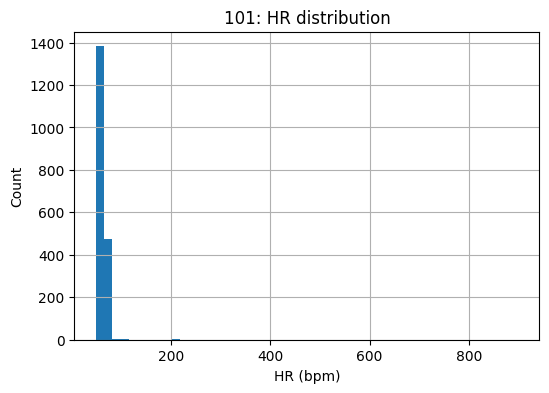

In [17]:
# Demo cho 1 record
rec_id = "101"
seconds_plot = 10

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]
r_peaks = np.asarray(ecg_data[rec_id]["r_peaks"], dtype=int)

sig_qc = qc_signal_metrics(ecg_raw, fs)
rr_qc  = qc_rr_metrics(r_peaks, fs)

qc_output = {
    "record_id": rec_id,
    "fs_hz": fs,
    "duration_s": len(ecg_raw)/fs,
    "num_beats": len(r_peaks),
    "baseline_std": sig_qc["baseline_std"],
    "baseline_ptp": sig_qc["baseline_ptp"],
    "powerline_50_ratio": sig_qc["powerline_50_ratio"],
    "powerline_60_ratio": sig_qc["powerline_60_ratio"],
    "hf_noise_ratio_20_40": sig_qc["hf_noise_ratio_20_40"],
    "amp_std": sig_qc["amp_std"],
    "amp_min": sig_qc["amp_min"],
    "amp_max": sig_qc["amp_max"],
    "rr_min": rr_qc["rr_min"],
    "rr_max": rr_qc["rr_max"],
    "bad_rr_pct": rr_qc["bad_rr_pct"],
}
display(pd.DataFrame([qc_output]))

plot_ecg_with_baseline(ecg_raw, sig_qc["baseline_series"], fs, seconds=seconds_plot,
                       title=f"{rec_id}: ECG raw + baseline (first {seconds_plot}s)")
ax = plot_psd_welch_with_60_harmonics(ecg_raw, fs=360, band_halfwidth=1.0, fmax=360)
plot_rr_hist(rr_qc["rr"], title=f"{rec_id}: RR distribution")
plot_hr_hist(rr_qc["rr"], title=f"{rec_id}: HR distribution")


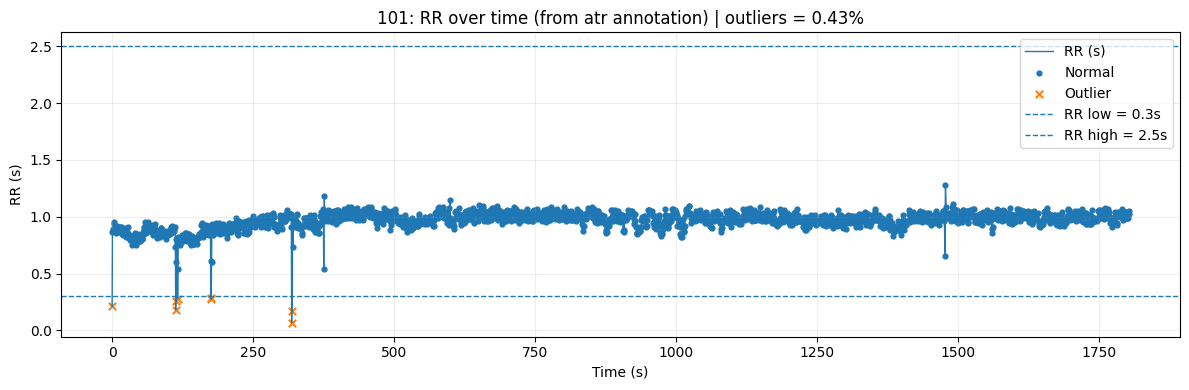

First 20 outlier RR indices: [  0 132 134 138 210 212 366 368]


In [18]:
# biểu đồ Outlier RR
#  Compute RR series
r_times = r_peaks / fs                 # time of each R-peak (s)
rr = np.diff(r_times)                  # RR intervals (s)
t_rr = (r_times[:-1] + r_times[1:]) / 2  # timestamp for each RR (midpoint)

#  Outlier rule
rr_low, rr_high = 0.3, 2.5
out_mask = (rr < rr_low) | (rr > rr_high)
bad_rr_pct = 100 * out_mask.mean() if len(rr) else 0

# chỉ vẽ 5 phút đầu
max_time = None  # ví dụ 300 để vẽ 5 phút đầu
if max_time is not None:
    keep = t_rr <= max_time
    t_rr, rr, out_mask = t_rr[keep], rr[keep], out_mask[keep]

# Plot RR over time + highlight outliers
plt.figure(figsize=(12, 4))
plt.plot(t_rr, rr, linewidth=1, label="RR (s)")
plt.scatter(t_rr[~out_mask], rr[~out_mask], s=12, label="Normal")
plt.scatter(t_rr[out_mask], rr[out_mask], s=28, marker="x", label="Outlier")

plt.axhline(rr_low, linestyle="--", linewidth=1, label=f"RR low = {rr_low}s")
plt.axhline(rr_high, linestyle="--", linewidth=1, label=f"RR high = {rr_high}s")

plt.title(f"{rec_id}: RR over time (from atr annotation) | outliers = {bad_rr_pct:.2f}%")
plt.xlabel("Time (s)")
plt.ylabel("RR (s)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

#  in ra index các RR outlier để bạn trace ngược
out_idx = np.where(out_mask)[0]
print("First 20 outlier RR indices:", out_idx[:20])


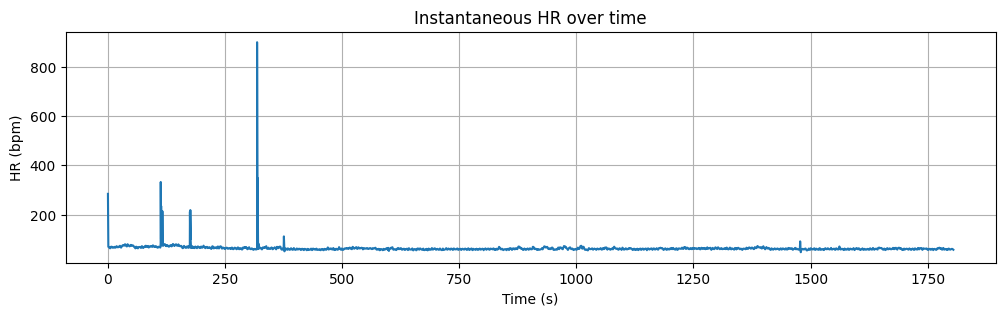

In [19]:
# biểu đồ chuỗi nhịp tim record 101
# RR & HR from R-peaks
rr = np.diff(r_peaks) / fs
hr = 60.0 / (rr + 1e-12)
t_beats = r_peaks[1:] / fs

# Plot HR time series
plt.figure(figsize=(12,3))
plt.plot(t_beats, hr)
plt.title("Instantaneous HR over time")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True)
plt.show()



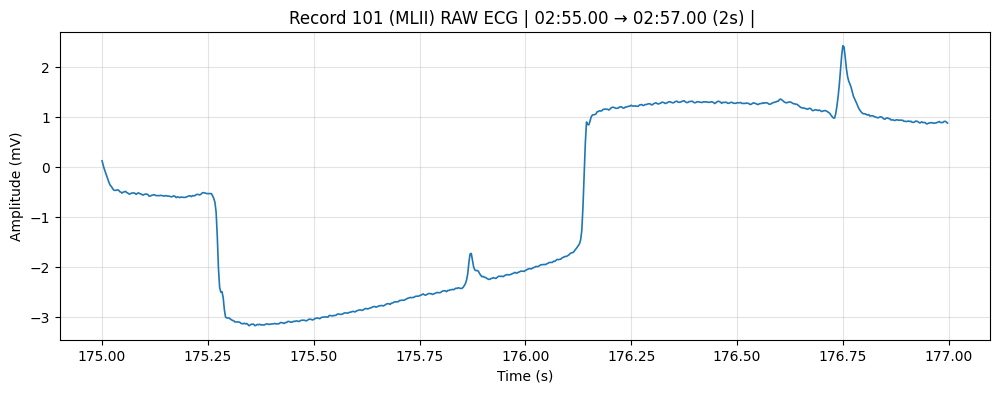

In [20]:
# visualize lỗi biên độ ECG thô trong record 101
rec_id = "101"
record = wfdb.rdrecord(rec_id, pn_dir="mitdb")
start_time_s = 2*60 + 55.00   # 175.00 s
dur_s = 2.0

start_idx = int(start_time_s * fs)   # = 63000 nếu fs=360
end_idx = start_idx + int(dur_s * fs)

t = np.arange(start_idx, end_idx) / fs
seg = ecg[start_idx:end_idx]

plt.figure(figsize=(12, 4))
plt.plot(t, seg, linewidth=1.2)
plt.title(f"Record 101 (MLII) RAW ECG | 02:55.00 → 02:57.00 (2s) | ")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.35)
plt.show()

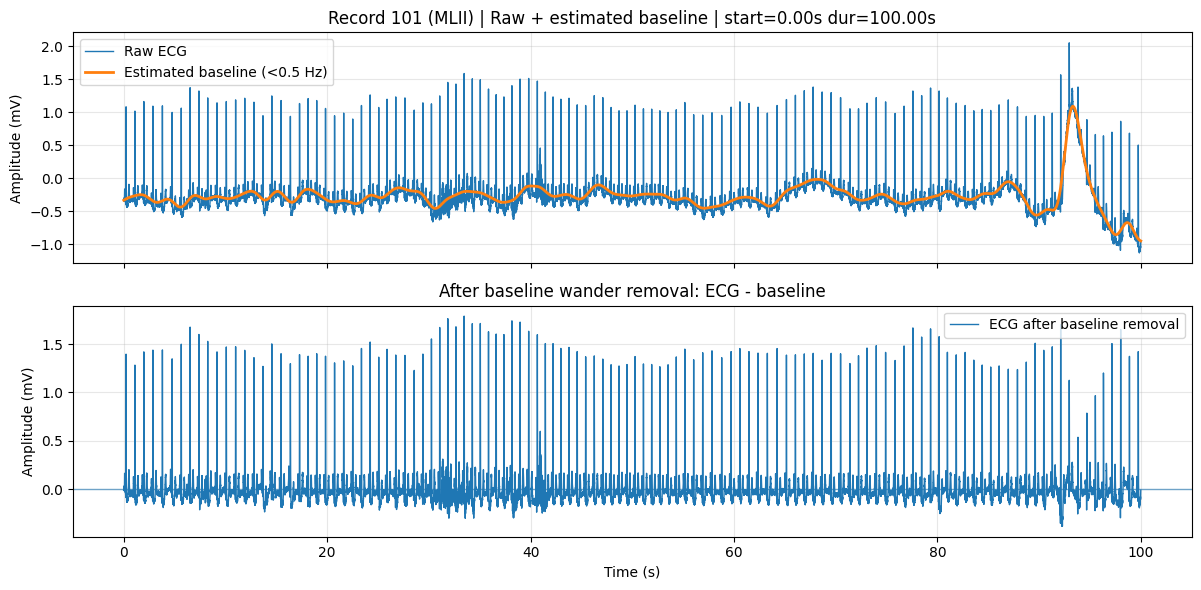

In [21]:
#visualize trôi nền và loại bỏ trôi nền bằng lọc thông thấp
def lowpass_baseline(x, fs, cutoff=0.5, order=4):
    """Ướine wc lượng baselander bằng low-pass Butterworth + filtfilt (zero-phase)."""
    x = np.asarray(x, dtype=float)
    nyq = fs / 2.0
    wn = cutoff / nyq
    b, a = butter(order, wn, btype="low")
    return filtfilt(b, a, x)

def remove_baseline_wander(ecg, fs, cutoff=0.5, order=4):
    baseline = lowpass_baseline(ecg, fs, cutoff=cutoff, order=order)
    ecg_detrend = ecg - baseline
    return baseline, ecg_detrend

def plot_baseline_removal(ecg, baseline, ecg_detrend, fs, start_s=0.0, dur_s=10.0,
                          title_prefix="Record 101 (MLII)"):
    i0 = int(start_s * fs)
    i1 = min(len(ecg), i0 + int(dur_s * fs))
    t = np.arange(i0, i1) / fs

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Plot 1: Raw + baseline
    axs[0].plot(t, ecg[i0:i1], linewidth=1.0, label="Raw ECG")
    axs[0].plot(t, baseline[i0:i1], linewidth=2.0, label="Estimated baseline (<0.5 Hz)")
    axs[0].set_title(f"{title_prefix} | Raw + estimated baseline | start={start_s:.2f}s dur={dur_s:.2f}s")
    axs[0].set_ylabel("Amplitude (mV)")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # Plot 2: Detrended
    axs[1].plot(t, ecg_detrend[i0:i1], linewidth=1.0, label="ECG after baseline removal")
    axs[1].axhline(0, linewidth=1.0, alpha=0.6)
    axs[1].set_title("After baseline wander removal: ECG - baseline")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Amplitude (mV)")
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# ====== Load record 101 ======
record = wfdb.rdrecord("101", pn_dir="mitdb")
fs = int(record.fs)
ecg = record.p_signal[:, 0]  # MLII

# ====== Remove baseline wander ======
baseline, ecg_detrend = remove_baseline_wander(ecg, fs, cutoff=0.5, order=4)

# ====== Visualize (chọn đoạn để nhìn rõ trôi nền) ======
plot_baseline_removal(ecg, baseline, ecg_detrend, fs, start_s=0, dur_s=100)


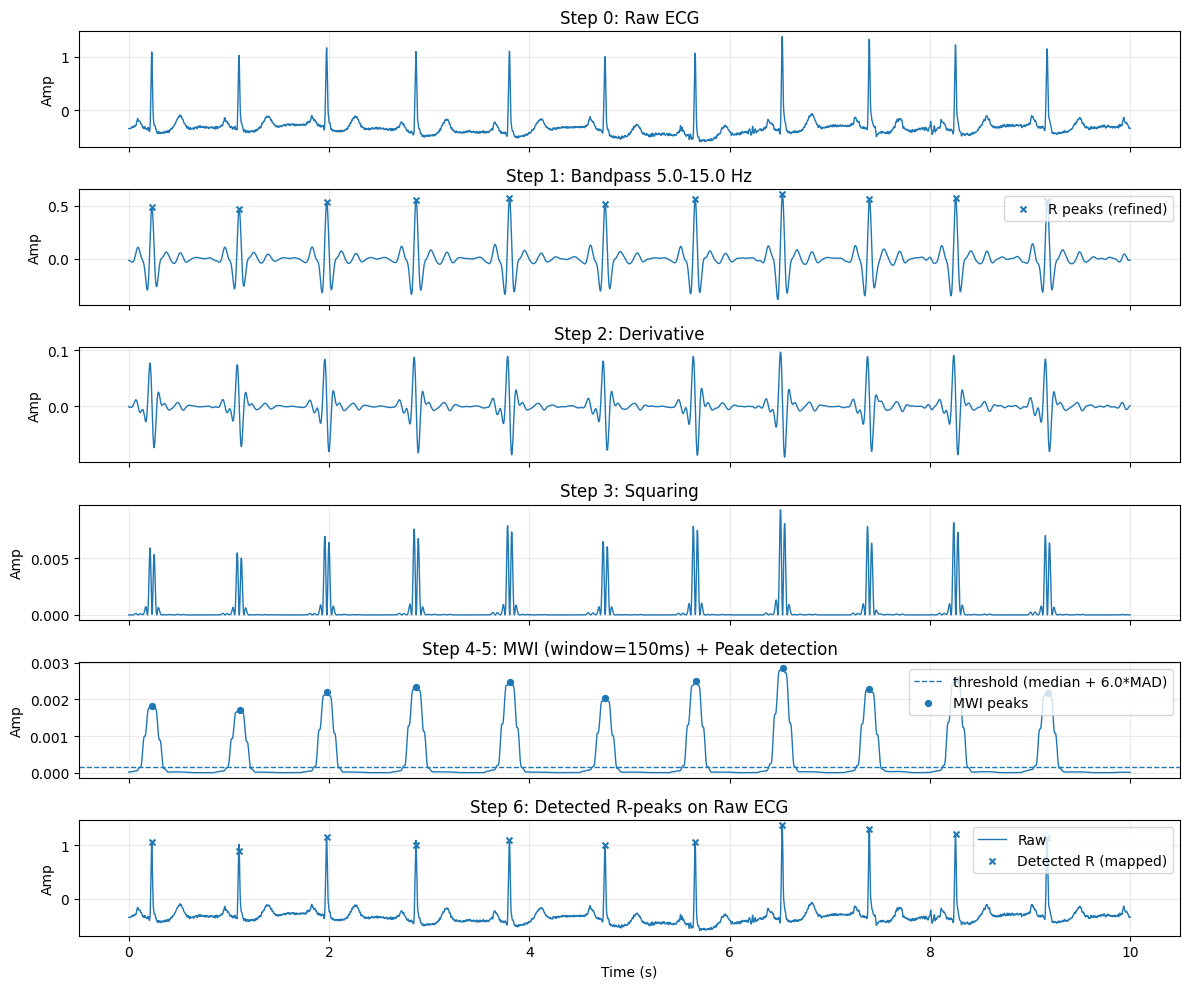

Detected R-peaks (sample indices): [  83  397  711 1033 1368 1712 2036 2349 2662 2972] ...
Detected R-peaks (seconds): [0.23055556 1.10277778 1.975      2.86944444 3.8        4.75555556
 5.65555556 6.525      7.39444444 8.25555556]


In [ ]:
# QRS detection steps with visualization
def bandpass(x, fs, low=5.0, high=15.0, order=3):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def moving_average(x, N):
    N = max(1, int(N))
    return np.convolve(x, np.ones(N)/N, mode="same")

def robust_threshold(x, k=6.0):
    # threshold = median + k*MAD (robust, ít bị spike kéo)
    x = np.asarray(x, float)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return med + k * mad

def qrs_steps_and_plot(ecg, fs, start_s=0.0, dur_s=10.0,
                       bp_low=5.0, bp_high=15.0,
                       mwi_ms=150,
                       thr_k=6.0,
                       refractory_ms=200):
    ecg = np.asarray(ecg, float)

    i0 = int(start_s * fs)
    i1 = min(len(ecg), i0 + int(dur_s * fs))
    x = ecg[i0:i1]
    t = np.arange(i0, i1) / fs

    # 1) Bandpass (QRS band)
    xf = bandpass(x, fs, low=bp_low, high=bp_high, order=3)

    # 2) Derivative
    d = np.diff(xf, prepend=xf[0])

    # 3) Squaring
    s = d**2

    # 4) Moving window integration
    N = int((mwi_ms/1000.0) * fs)
    m = moving_average(s, N)

    # 5) Detect peaks on MWI
    thr = robust_threshold(m, k=thr_k)
    refractory = int((refractory_ms/1000.0) * fs)
    peaks_m, props = find_peaks(m, height=thr, distance=refractory)

    # 6) Refine R-peaks: search max in xf around each MWI peak
    search = int(0.15 * fs)  # ±150ms
    r_peaks = []
    for p in peaks_m:
        a = max(0, p - search)
        b = min(len(xf), p + search + 1)
        r = a + np.argmax(xf[a:b])
        r_peaks.append(r)
    r_peaks = np.array(r_peaks, dtype=int)

    # ===== Plot steps =====
    fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

    axs[0].plot(t, x, lw=1.0)
    axs[0].set_title("Step 0: Raw ECG")

    axs[1].plot(t, xf, lw=1.0)
    axs[1].scatter(t[r_peaks], xf[r_peaks], s=18, marker="x", label="R peaks (refined)")
    axs[1].legend(loc="upper right")
    axs[1].set_title(f"Step 1: Bandpass {bp_low}-{bp_high} Hz")

    axs[2].plot(t, d, lw=1.0)
    axs[2].set_title("Step 2: Derivative")

    axs[3].plot(t, s, lw=1.0)
    axs[3].set_title("Step 3: Squaring")

    axs[4].plot(t, m, lw=1.0)
    axs[4].axhline(thr, ls="--", lw=1.0, label=f"threshold (median + {thr_k}*MAD)")
    axs[4].scatter(t[peaks_m], m[peaks_m], s=18, marker="o", label="MWI peaks")
    axs[4].legend(loc="upper right")
    axs[4].set_title(f"Step 4-5: MWI (window={mwi_ms}ms) + Peak detection")

    # Overlay: raw vs detected R for sanity
    axs[5].plot(t, x, lw=1.0, label="Raw")
    axs[5].scatter(t[r_peaks], x[r_peaks], s=18, marker="x", label="Detected R (mapped)")
    axs[5].legend(loc="upper right")
    axs[5].set_title("Step 6: Detected R-peaks on Raw ECG")

    for ax in axs:
        ax.grid(True, alpha=0.25)
        ax.set_ylabel("Amp")
    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

    # trả về chỉ số mẫu theo toàn record (cộng offset i0)
    return (r_peaks + i0), (peaks_m + i0)

# ===== Load record 101 =====
record = wfdb.rdrecord("101", pn_dir="mitdb")
fs = int(record.fs)
ecg = record.p_signal[:, 0]  # MLII

# Visualize 10s để nhìn rõ từng bước
r_peaks, mwi_peaks = qrs_steps_and_plot(ecg, fs, start_s=0.0, dur_s=10.0)

print("Detected R-peaks (sample indices):", r_peaks[:10], "...")
print("Detected R-peaks (seconds):", (r_peaks[:10]/fs))
